# Interactive test drive: probabilistic tracking pipeline

Tests the full data path on real files: FLEXTRKR masks → association targets →
temporal windows → aligned ERA5 inputs → (untrained) TrackerNet forward pass.

Runs on NCAR (Casper/Derecho, `npl` kernel or any env with `xarray`; the model
cells additionally need `torch`). The mask cells also run locally if
`sample_data/` holds the June 1 2005 files.


In [1]:
import os, sys, glob
import numpy as np
import matplotlib.pyplot as plt

# make repo modules importable regardless of where the notebook was launched
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import tracking_targets as tt
import dataset_temporal as dt

# resolve data locations: NCAR glade if available, else local sample_data
GLADE_MASKS = '/glade/derecho/scratch/molina/cesm_mcs/mcs_flextrkr_era5/mcstracking_3pctl/2005'
LOCAL_MASKS = os.path.join('..', 'sample_data')
MASK_DIR = GLADE_MASKS if os.path.isdir(GLADE_MASKS) else LOCAL_MASKS
ERA5_ACCUM = '/glade/campaign/collections/rda/data/d633000/e5.oper.fc.sfc.accumu'
print('masks from:', MASK_DIR)
print('ERA5 archive available:', os.path.isdir(ERA5_ACCUM))

Matplotlib is building the font cache; this may take a moment.


masks from: ../sample_data
ERA5 archive available: False


## 1. Association targets for a real split

June 1 2005, 08Z → 09Z: storm 76 splits into (76, 78). The forward matrix row
for 76 should place large mass on both children.


In [2]:
f0 = os.path.join(MASK_DIR, 'mcstrack_20050601_0800.nc')
f1 = os.path.join(MASK_DIR, 'mcstrack_20050601_0900.nc')
out = tt.build_targets(f0, f1)

print('storms at t  :', out['ids_t0'])
print('storms at t+1:', out['ids_t1'])
print()
for e in out['events']:
    print(e)

storms at t  : [73, 76, 77]
storms at t+1: [73, 76, 77, 78]

{'kind': 'split', 'ids_t0': [76], 'ids_t1': [76, 78]}
{'kind': 'continuation', 'ids_t0': [73], 'ids_t1': [73]}
{'kind': 'continuation', 'ids_t0': [77], 'ids_t1': [77]}


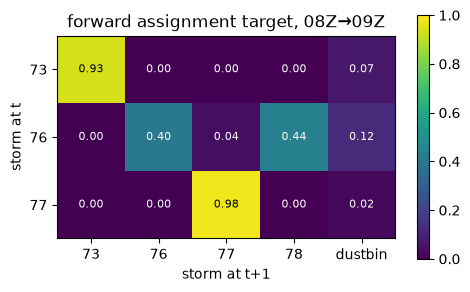

row sums OK — every row is a probability distribution


In [4]:
# forward matrix, rows = storms at t, cols = storms at t+1 plus dustbin
fwd = out['forward']
fig, ax = plt.subplots(figsize=(5, 3))
im = ax.imshow(fwd, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(len(out['ids_t1']) + 1))
ax.set_xticklabels([str(j) for j in out['ids_t1']] + ['dustbin'])
ax.set_yticks(range(len(out['ids_t0'])))
ax.set_yticklabels([str(i) for i in out['ids_t0']])
ax.set_xlabel('storm at t+1'); ax.set_ylabel('storm at t')
for a in range(fwd.shape[0]):
    for b in range(fwd.shape[1]):
        ax.text(b, a, f'{fwd[a,b]:.2f}', ha='center', va='center',
                color='white' if fwd[a,b] < 0.6 else 'black', fontsize=8)
plt.colorbar(im); plt.title('forward assignment target, 08Z→09Z')
plt.tight_layout(); plt.show()

assert np.allclose(fwd.sum(axis=1), 1.0), 'rows must sum to 1'
print('row sums OK — every row is a probability distribution')

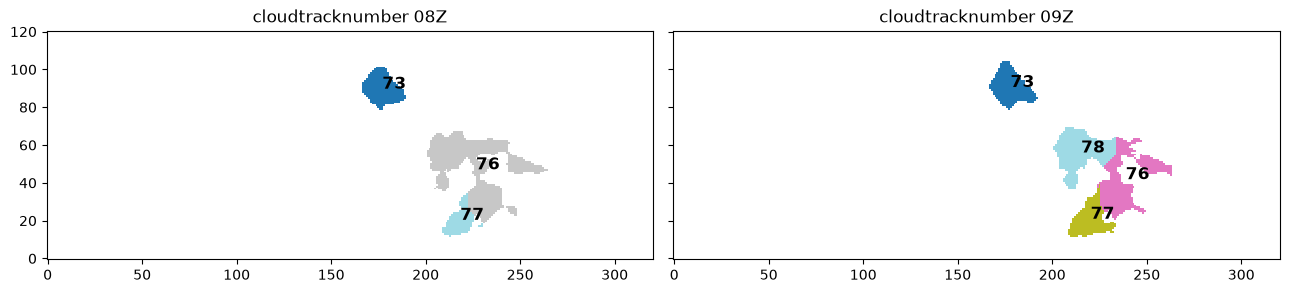

In [5]:
# the masks themselves, for eyeballing the split
m0, m1 = tt.load_mask(f0), tt.load_mask(f1)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
for ax, m, title in [(axes[0], m0, '08Z'), (axes[1], m1, '09Z')]:
    shown = np.where(m == 0, np.nan, m)
    ax.imshow(shown, origin='lower', cmap='tab20', interpolation='nearest')
    ax.set_title(f'cloudtracknumber {title}')
    for i in np.unique(m)[1:]:
        yy, xx = np.where(m == i)
        ax.text(xx.mean(), yy.mean(), str(int(i)), fontsize=12, weight='bold')
plt.tight_layout(); plt.show()

## 2. Temporal windows


In [6]:
files = sorted(glob.glob(os.path.join(MASK_DIR, 'mcstrack_20050601_*.nc')))
ds = dt.TemporalMaskDataset(files, window=3)
print(f'{len(files)} files -> {len(ds)} windows of 3 consecutive hours')

item = ds[7]   # covers 07-09Z; second pair holds the split
print('times:', item['times'])
print('track_masks:', tuple(item['track_masks'].shape), '| targets per window:', len(item['targets']))
print('events in second pair:', [e['kind'] for e in item['targets'][1]['events']])

24 files -> 22 windows of 3 consecutive hours
times: ['2005-06-01T07:00:00', '2005-06-01T08:00:00', '2005-06-01T09:00:00']
track_masks: (3, 121, 321) | targets per window: 2
events in second pair: ['split', 'continuation', 'continuation']


## 3. ERA5 input alignment (NCAR only)

Loads raw OLR/TTR for the same hours from the permanent RDA archive and
overlays the mask outline — the storm blobs should sit on the cold (bright)
OLR features if the alignment (slice + latitude flip) is right.


In [7]:
if os.path.isdir(ERA5_ACCUM):
    import dataset_inputs as di
    ld = di.ERA5ForecastLoader(ERA5_ACCUM)
    w = ld.window(item['times'])
    print('input window shape:', w.shape)   # (3, 1, 121, 321)

    fig, axes = plt.subplots(1, 3, figsize=(16, 3.2), sharey=True)
    for k, ax in enumerate(axes):
        ax.imshow(w[k, 0], origin='lower', cmap='gray_r')
        ax.contour(item['track_masks'][k].numpy() > 0, colors='red', linewidths=0.8)
        ax.set_title(item['times'][k])
    plt.suptitle('-TTR (OLR-like) with FLEXTRKR mask outlines')
    plt.tight_layout(); plt.show()
else:
    print('ERA5 archive not visible from this machine — run on Casper/Derecho')

ERA5 archive not visible from this machine — run on Casper/Derecho


### Accumulation check (decides the `difference` flag)

If mean |TTR| grows steadily from forecast hour 1 to 12, values are cumulative
since init and the loader should use `difference=True`; if roughly flat, they
are already hourly and the default is correct.


In [8]:
if os.path.isdir(ERA5_ACCUM):
    import xarray as xr
    f = sorted(glob.glob(os.path.join(ERA5_ACCUM, '200506', '*128_179_ttr*.nc')))[0]
    with xr.open_dataset(f) as dsx:
        v = dsx['TTR'].isel(forecast_initial_time=0).mean(dim=('latitude', 'longitude')).values
    plt.plot(range(1, 13), np.abs(v) / 1e5, marker='o')
    plt.xlabel('forecast hour'); plt.ylabel('mean |TTR| / 1e5')
    plt.title('cumulative (rising) vs hourly (flat)?'); plt.show()

## 4. Untrained model forward pass (needs torch)

Wires everything together: real inputs + real masks through TrackerNet.
Untrained, so predictions are noise — this checks shapes, alignment, and that
the loss computes and backpropagates on real data.


In [9]:
try:
    import torch
    import tracker_model as tm
    HAVE_TORCH = True
except ImportError:
    HAVE_TORCH = False
    print('torch not in this kernel — pick/build an env with pytorch for this section')

In [10]:
if HAVE_TORCH and os.path.isdir(ERA5_ACCUM):
    net = tm.TrackerNet(n_channels=1, n_classes=2)
    x = torch.from_numpy(w).float().unsqueeze(0)          # (1, 3, 1, 121, 321)
    # pad lat 121 -> 128 so the U-Net's four 2x downsamplings divide evenly
    x = torch.nn.functional.pad(x, (0, 0, 3, 4))
    feats, logits = net(x)
    print('features:', tuple(feats.shape), '| seg logits:', tuple(logits.shape))

    masks = torch.nn.functional.pad(item['track_masks'], (0, 0, 3, 4))
    ids0, ids1, pf, pb = net.associate(feats[0, 1], feats[0, 2], masks[1], masks[2])
    print('predicted forward matrix (untrained, ~uniform):')
    print(np.round(pf.detach().numpy(), 3))
    print('target forward matrix:')
    print(np.round(item['targets'][1]['forward'].numpy(), 3))

    loss = tm.tracking_loss(logits[0], (masks > 0).long(),
                            [(pf, pb)], [item['targets'][1]])
    loss.backward()
    print('loss on real data:', float(loss), '— backward pass OK')

If every section ran: the full pipeline works on real data end-to-end, and
the only thing between here and results is training. 🌩️
